# Импорты и вспомогательные функции

In [1]:
import warnings
warnings.filterwarnings('ignore')

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict
from IPython.display import display, HTML

import umap
from scipy.spatial.distance import cdist
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import DBSCAN, KMeans
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.calibration import CalibratedClassifierCV

from catboost import CatBoostClassifier, CatBoostRegressor
from causalml.inference.tree import UpliftRandomForestClassifier
from sklift.datasets import fetch_x5
from sklift.models import TwoModels
import sklearn.utils
def dummy_check_matplotlib_support(*args, **kwargs):
    pass
sklearn.utils.check_matplotlib_support = dummy_check_matplotlib_support

from sklift.viz import plot_qini_curve, plot_uplift_curve

from sklift.metrics import (
    uplift_auc_score,
    qini_auc_score,
    weighted_average_uplift,
    uplift_at_k,
    uplift_by_percentile
)
from sklift.viz import plot_uplift_by_percentile

# Настройки графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

if parent_dir not in os.sys.path:
    os.sys.path.append(parent_dir)

from helpers.feature_extraction_expanded import *
from helpers.classic_ml_models import *
from helpers.clusterization_features_extraction import *

In [2]:
# Фиксим вечную проблему sklift-модуля в визуализации графиков

import sklearn.utils
import sklift.viz.base as sklift_viz
import matplotlib.pyplot as plt

# Лечим проверку matplotlib
sklearn.utils.check_matplotlib_support = lambda *args, **kwargs: None

def patched_plot(self, auc_score=None, ax=None, name=None, title='AUC', **kwargs):
    if ax is None:
        _, ax = plt.subplots()

    display_name = name if name else getattr(self, 'estimator_name', None)
    
    label = f"{display_name} (AUC={auc_score:.4f})" if display_name else f"AUC={auc_score:.4f}"
    
    plot_kwargs = {k: v for k, v in kwargs.items() if k not in ['perfect', 'random']}
    
    # Рисуем основную линию
    ax.plot(self.x_actual, self.y_actual, label=label, linewidth=kwargs.get('lw', 2), **plot_kwargs)

    # Рисуем Random линию только один раз на весь график
    handles, labels = ax.get_legend_handles_labels()
    x_base = getattr(self, 'x_baseline', None)
    y_base = getattr(self, 'y_baseline', None)

    if x_base is not None and "Random" not in labels:
        ax.plot(x_base, y_base, label="Random", color="red", linestyle="--", linewidth=1.5, alpha=0.7)
    
    # Подписи осей в зависимости от масштаба
    if self.x_actual[-1] <= 1.1:
        ax.set_xlabel("Percent of population targeted")
        ax.set_ylabel("Incremental Outcome (Qini)")
    else:
        ax.set_xlabel("Number targeted")
        ax.set_ylabel("Cumulative Uplift")
    
    return self

# Перезаписываем метод
sklift_viz.UpliftCurveDisplay.plot = patched_plot

In [26]:
# У реализации sklift не получается связка с текущей версией numpy, которую мы поставили для работы causalml на UpliftTree, поэтому напишем собственные графики

def get_uplift_percentile_table(y_true, uplift_preds, treatment, bins=10):
    y_true = np.asarray(y_true).reshape(-1)
    uplift_preds = np.asarray(uplift_preds).reshape(-1)
    treatment = np.asarray(treatment).reshape(-1)

    df = uplift_by_percentile(
        y_true=y_true,
        uplift=uplift_preds,
        treatment=treatment,
        strategy='overall',
        bins=bins,
        std=False,
        total=False,
        string_percentiles=True
    ).reset_index()

    if 'index' in df.columns:
        df = df.rename(columns={'index': 'percentile'})

    # На всякий случай приводим к числам
    numeric_cols = [
        'n_treatment',
        'n_control',
        'response_rate_treatment',
        'response_rate_control',
        'uplift'
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Стандартные ошибки для error bars
    p_t = df['response_rate_treatment'].to_numpy()
    p_c = df['response_rate_control'].to_numpy()
    n_t = df['n_treatment'].to_numpy()
    n_c = df['n_control'].to_numpy()

    se_t = np.sqrt(np.where(n_t > 0, p_t * (1 - p_t) / n_t, np.nan))
    se_c = np.sqrt(np.where(n_c > 0, p_c * (1 - p_c) / n_c, np.nan))
    se_u = np.sqrt(np.nan_to_num(se_t, nan=0.0) ** 2 + np.nan_to_num(se_c, nan=0.0) ** 2)

    df['se_treatment'] = se_t
    df['se_control'] = se_c
    df['se_uplift'] = se_u

    return df

def plot_percentile_grid(preds_dict, y_true, treatment, split_name, bins=10):
    model_names = list(preds_dict.keys())

    fig = plt.figure(figsize=(18, 14))
    outer = fig.add_gridspec(2, 2, wspace=0.22, hspace=0.28)

    for i, model_name in enumerate(model_names):
        row, col = divmod(i, 2)

        inner = outer[row, col].subgridspec(
            2, 1,
            height_ratios=[1, 1.05],
            hspace=0.18
        )

        ax_top = fig.add_subplot(inner[0])
        ax_bottom = fig.add_subplot(inner[1], sharex=ax_top)

        preds = preds_dict[model_name]
        df = get_uplift_percentile_table(
            y_true=y_true,
            uplift_preds=preds,
            treatment=treatment,
            bins=bins
        )

        wau = weighted_average_uplift(y_true, preds, treatment)

        x = np.arange(len(df))
        width = 0.36

        # Верхний график: uplift by percentile
        ax_top.bar(
            x,
            df['uplift'],
            yerr=df['se_uplift'],
            capsize=2,
            color='red',
            alpha=0.95,
            edgecolor='black',
            linewidth=0.3,
            label='uplift'
        )
        ax_top.axhline(0, color='black', linewidth=1)

        ax_top.set_title(
            f'{model_name}\nUplift by percentile\nweighted average uplift = {wau:.4f}',
            fontsize=11,
            fontweight='bold'
        )
        ax_top.set_ylabel('Uplift = treatment response rate - control response rate', fontsize=10)
        ax_top.legend(loc='upper right', fontsize=9, frameon=True)
        ax_top.grid(axis='y', linestyle='--', alpha=0.35)
        ax_top.tick_params(axis='x', labelbottom=False)

        # Нижний график: response rate by percentile
        ax_bottom.bar(
            x - width / 2,
            df['response_rate_treatment'],
            width=width,
            yerr=df['se_treatment'],
            capsize=2,
            color='forestgreen',
            alpha=0.95,
            edgecolor='black',
            linewidth=0.3,
            label='treatment\nresponse rate'
        )

        ax_bottom.bar(
            x + width / 2,
            df['response_rate_control'],
            width=width,
            yerr=df['se_control'],
            capsize=2,
            color='orange',
            alpha=0.95,
            edgecolor='black',
            linewidth=0.3,
            label='control\nresponse rate'
        )

        ax_bottom.set_title('Response rate by percentile', fontsize=11, fontweight='bold')
        ax_bottom.set_ylabel('response rate', fontsize=10)
        ax_bottom.set_xlabel('Percentile', fontsize=10)
        ax_bottom.set_xticks(x)
        ax_bottom.set_xticklabels(df['percentile'], rotation=35)
        ax_bottom.legend(loc='upper right', fontsize=9, frameon=True)
        ax_bottom.grid(axis='y', linestyle='--', alpha=0.35)

    # fig.suptitle(f'Uplift by percentile | {split_name}', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.985])

    return fig

In [4]:
def calculate_metrics(y_true, uplift_preds, treatment):
    return {
        "AUUC": uplift_auc_score(y_true, uplift_preds, treatment),
        "Qini": qini_auc_score(y_true, uplift_preds, treatment),
        "WAU": weighted_average_uplift(y_true, uplift_preds, treatment),
        "Uplift_at_10_perc": uplift_at_k(y_true, uplift_preds, treatment, strategy='overall', k=0.1),
        "Uplift_at_20_perc": uplift_at_k(y_true, uplift_preds, treatment, strategy='overall', k=0.2),
        "Uplift_at_30_perc": uplift_at_k(y_true, uplift_preds, treatment, strategy='overall', k=0.3),
        "Uplift_at_50_perc": uplift_at_k(y_true, uplift_preds, treatment, strategy='overall', k=0.5)
    }

# Подготовка MLflow

In [45]:
os.environ["MLFLOW_TRACKING_URI"] = "http://localhost:5000"
os.environ["MLFLOW_S3_ENDPOINT_URL"] = "http://localhost:9000"
os.environ["AWS_ACCESS_KEY_ID"] = "minioadmin"
os.environ["AWS_SECRET_ACCESS_KEY"] = "minioadmin"

In [46]:
import mlflow
import mlflow.catboost
import mlflow.sklearn

# Фиксация seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Настройка MLflow
mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI", "http://localhost:5000"))
mlflow.set_experiment("X-Learner CatBoost")

print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")

2026/05/29 17:31:43 INFO mlflow.tracking.fluent: Experiment with name 'X-Learner CatBoost' does not exist. Creating a new experiment.


MLflow tracking URI: http://localhost:5000


# Подготовка датасета

In [7]:
dataset = fetch_x5()
data = dataset.data

In [8]:
extractor = UpliftFeatureExtractorExpanded(drop_redundant=True)
df = extractor.calculate_features(
    clients_df=data.clients,
    train_df=data.train,
    treatment_df=dataset.treatment,
    target_df=dataset.target,
    purchases_df=data.purchases
)

del data, dataset
gc.collect()

features = extractor.feature_names
TARGET_COL = "target"
TREATMENT_COL = "treatment_flg"

X_all = df[features].copy()
y_all = df[TARGET_COL].values
t_all = df[TREATMENT_COL].values

print(f"Размер итогового датасета: {X_all.shape}")

Размер итогового датасета: (200039, 45)


In [9]:
strata_all = pd.Series(t_all).astype(str) + '_' + pd.Series(y_all).astype(str)

x_train_full, x_test_holdout, y_train_full, y_test_holdout, t_train_full, t_test_holdout = train_test_split(
    X_all,
    y_all,
    t_all,
    test_size=0.2,
    random_state=42,
    stratify=strata_all
)

print(x_train_full.shape, x_test_holdout.shape)

(160031, 45) (40008, 45)


In [10]:
current_num_cols = x_train_full.select_dtypes(include=['number']).columns.tolist()
clusterizer_full = UmapClusterTransformer(num_cols=current_num_cols, n_clusters=5)

x_train_full_clust = clusterizer_full.fit_transform(x_train_full)
x_test_holdout_clust = clusterizer_full.transform(x_test_holdout)

cat_cols_full = x_train_full_clust.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols_full = x_train_full_clust.select_dtypes(include=['number']).columns.tolist()

# Обучение и логирование X-learner

In [66]:
with mlflow.start_run() as run:
    run_id = run.info.run_id
    print(f"MLflow run ID: {run_id}")

    mlflow.log_params({f"outcome_model_{k}": v for k, v in XL_OUTCOME_CATBOOST_PARAMS.items()})
    mlflow.log_params({f"effect_model_{k}": v for k, v in XL_EFFECT_CATBOOST_PARAMS.items()})
    mlflow.log_params({f"propensity_model_{k}": v for k, v in XL_PROPENSITY_CATBOOST_PARAMS.items()})

    # Обучение
    x_learner_full = build_x_learner_catboost(cat_features=cat_cols_full, use_calibration=True)
    x_learner_full.outcome_learner = CalibratedClassifierCV(x_learner_full.outcome_learner, method='isotonic', cv=3)
    x_learner_full.propensity_learner = CalibratedClassifierCV(x_learner_full.propensity_learner, method='isotonic', cv=3)
    x_learner_full.fit(x_train_full_clust, y_train_full, t_train_full)

    # Делаем предикты
    preds_x_test = x_learner_full.predict(x_test_holdout_clust)
    test_holdout_preds = {'X-Learner (CatBoost)': preds_x_test}

    # Сохраяем метрики
    metrics = calculate_metrics(y_test_holdout, preds_x_test, t_test_holdout)
    mlflow.log_metrics(metrics)

    # Сохраняем модели
    mlflow.catboost.log_model(x_learner_full.model_tau_0, "model_tau_0", registered_model_name="model_tau_0")
    mlflow.catboost.log_model(x_learner_full.model_tau_1, "model_tau_1", registered_model_name="model_tau_1")
    mlflow.sklearn.log_model(x_learner_full.model_propensity, "model_propensity", registered_model_name="model_propensity")

MLflow run ID: 28dce456d10f4404b8372ee4d7f4aa15
0:	learn: 0.6833568	total: 55.8ms	remaining: 8.15s
100:	learn: 0.5575726	total: 6.08s	remaining: 2.77s
146:	learn: 0.5551200	total: 8.89s	remaining: 0us
0:	learn: 0.6837294	total: 53.8ms	remaining: 7.86s
100:	learn: 0.5585779	total: 6.04s	remaining: 2.75s
146:	learn: 0.5559906	total: 8.78s	remaining: 0us
0:	learn: 0.6836681	total: 55.1ms	remaining: 8.04s
100:	learn: 0.5576107	total: 6.24s	remaining: 2.84s
146:	learn: 0.5550555	total: 9.04s	remaining: 0us
0:	learn: 0.6827809	total: 54.9ms	remaining: 8.01s
100:	learn: 0.5491221	total: 5.99s	remaining: 2.73s
146:	learn: 0.5463386	total: 8.72s	remaining: 0us
0:	learn: 0.6832013	total: 59.3ms	remaining: 8.66s
100:	learn: 0.5456513	total: 5.89s	remaining: 2.68s
146:	learn: 0.5425847	total: 8.55s	remaining: 0us
0:	learn: 0.6831383	total: 54.2ms	remaining: 7.91s
100:	learn: 0.5474400	total: 5.69s	remaining: 2.59s
146:	learn: 0.5444776	total: 8.29s	remaining: 0us
0:	learn: 0.4362073	total: 30.6ms	

Registered model 'model_tau_0' already exists. Creating a new version of this model...
2026/05/29 17:58:12 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: model_tau_0, version 2
Created version '2' of model 'model_tau_0'.
Registered model 'model_tau_1' already exists. Creating a new version of this model...
2026/05/29 17:58:15 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: model_tau_1, version 2
Created version '2' of model 'model_tau_1'.
Registered model 'model_propensity' already exists. Creating a new version of this model...
2026/05/29 17:58:19 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: model_propensity, version 2
Created version '2' of model 'model_propensity'.


In [67]:
test_results_df = pd.DataFrame([{'Model': 'X-Learner (CatBoost)', 'Split': 'test_holdout', **metrics}])
display(test_results_df)

,Model,Split,AUUC,Qini,WAU,Uplift_at_10_perc,Uplift_at_20_perc,Uplift_at_30_perc,Uplift_at_50_perc
0,X-Learner (CatBoost),test_holdout,0.022245,0.014546,0.034055,0.115521,0.08224,0.069765,0.044431


# Артефакты (графики)

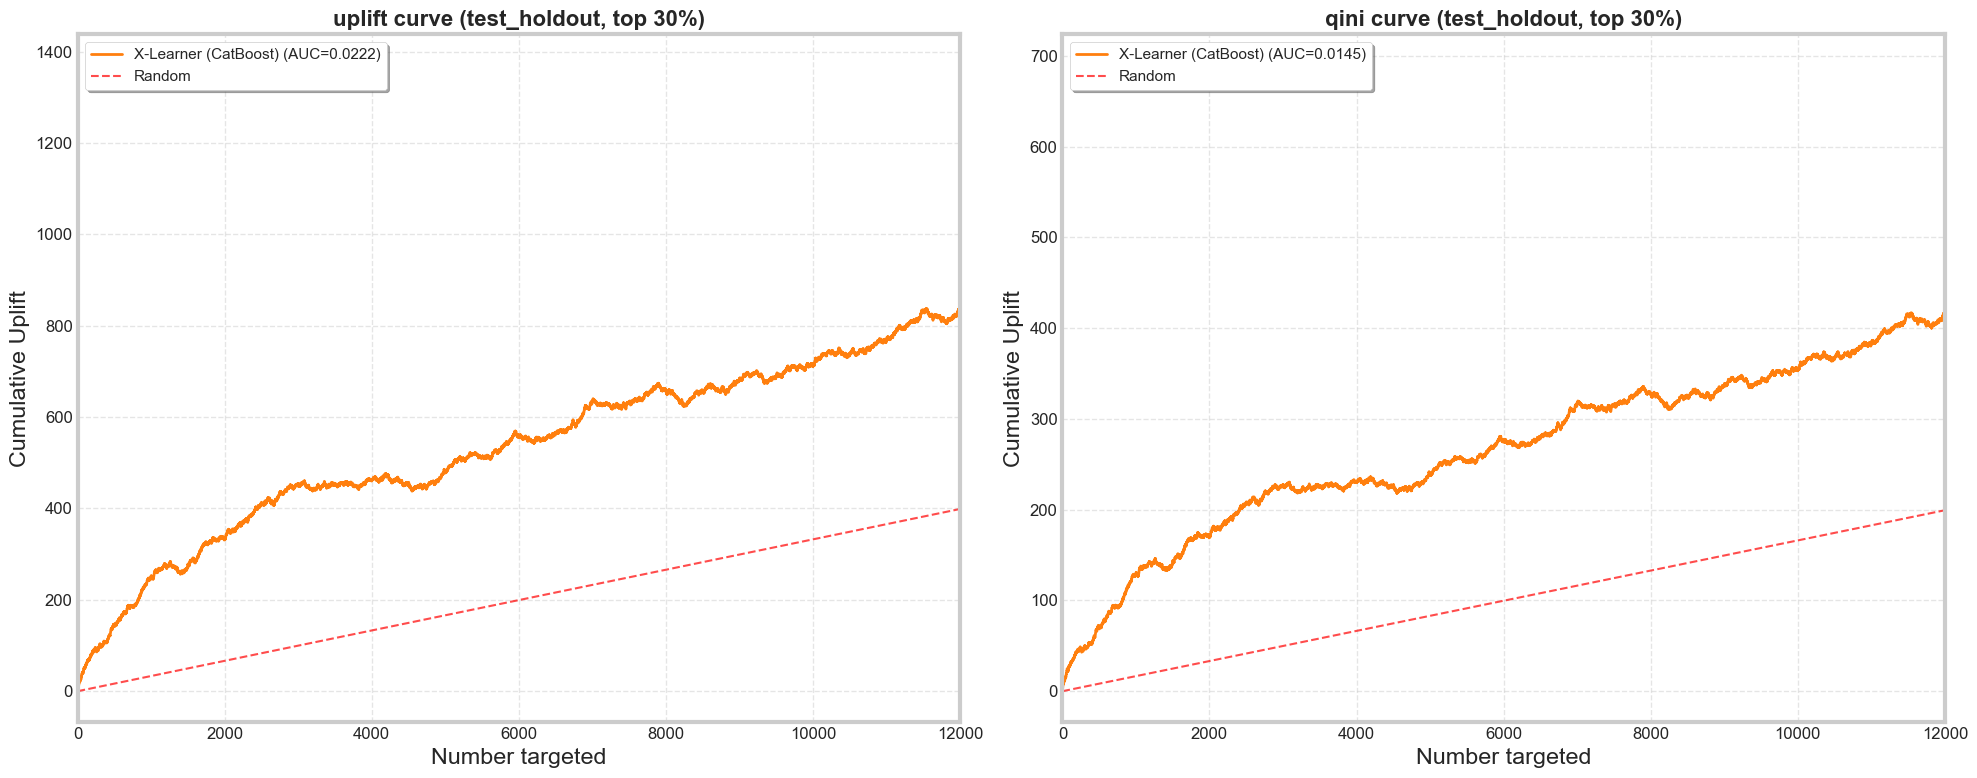

In [68]:
with mlflow.start_run(run_id=run_id):
    top_k_percent = 0.3
    
    model_colors = {
        "X-Learner (CatBoost)": "#ff7f0e"
    }
    
    model_styles = {
        "X-Learner (CatBoost)": {"ls": "-", "alpha": 1.0}
    }
    
    split_specs = {
        "test_holdout": {
            "y": y_test_holdout,
            "t": t_test_holdout,
            "preds_dict": test_holdout_preds
        }
    }
    
    for split_name, split_data in split_specs.items():
        y_split = split_data["y"]
        t_split = split_data["t"]
        preds_dict = split_data["preds_dict"]
    
        max_x = int(len(y_split) * top_k_percent)
    
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
        for model_name, preds in preds_dict.items():
            style = model_styles.get(model_name, {"ls": "-", "alpha": 0.8})
            color = model_colors.get(model_name, "gray")
    
            plot_uplift_curve(
                y_split,
                preds,
                t_split,
                name=model_name,
                ax=axes[0],
                color=color,
                perfect=False,
                **style
            )
    
            plot_qini_curve(
                y_split,
                preds,
                t_split,
                name=model_name,
                ax=axes[1],
                color=color,
                perfect=False,
                **style
            )
    
        axes[0].set_title(f"uplift curve ({split_name}, top 30%)", fontsize=16, fontweight='bold')
        axes[1].set_title(f"qini curve ({split_name}, top 30%)", fontsize=16, fontweight='bold')
    
        for ax in axes:
            ax.set_xlim(0, max_x)
            ax.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
            ax.grid(True, which='both', linestyle='--', alpha=0.5)
            ax.tick_params(axis='both', which='major', labelsize=12)
    
        plt.tight_layout()

        mlflow.log_figure(fig, "uplift_curves.png")
        plt.show()

In [69]:
percentile_frames = []

for model_name, preds in test_holdout_preds.items():
    df_test_pct = uplift_by_percentile(
        y_true=y_test_holdout,
        uplift=preds,
        treatment=t_test_holdout,
        strategy='overall',
        bins=10,
        std=False,
        total=False,
        string_percentiles=True
    ).reset_index().rename(columns={'index': 'percentile'})

    df_test_pct['Model'] = model_name
    df_test_pct['Split'] = 'test_holdout'
    percentile_frames.append(df_test_pct)

all_percentiles_df = pd.concat(percentile_frames, ignore_index=True)

for col in ['n_treatment', 'n_control']:
    all_percentiles_df[col] = all_percentiles_df[col].round().astype('Int64')

all_percentiles_df['n_total'] = all_percentiles_df['n_treatment'] + all_percentiles_df['n_control']

In [70]:
split_name = 'test_holdout'

split_percentiles_df = all_percentiles_df[all_percentiles_df['Split'] == split_name].copy()

pivot_uplift = split_percentiles_df.pivot(index='percentile', columns='Model', values='uplift').reset_index()
pivot_n_treat = split_percentiles_df.pivot(index='percentile', columns='Model', values='n_treatment').reset_index()
pivot_n_ctrl = split_percentiles_df.pivot(index='percentile', columns='Model', values='n_control').reset_index()
pivot_n_total = split_percentiles_df.pivot(index='percentile', columns='Model', values='n_total').reset_index()

display_df = pivot_uplift.copy()
display_df = display_df.rename(columns={'percentile': 'Перцентиль (бакет)'})
model_columns = [col for col in display_df.columns if col != 'Перцентиль (бакет)']

for model in model_columns:
    display_df[model] = (
        pivot_uplift[model].apply(lambda x: f'{x:+.2%}' if pd.notna(x) else 'nan')
        + '\n' +
        'n=' + pivot_n_total[model].apply(lambda x: f'{int(x)}' if pd.notna(x) else 'nan')
        + ', t=' + pivot_n_treat[model].apply(lambda x: f'{int(x)}' if pd.notna(x) else 'nan')
        + ', c=' + pivot_n_ctrl[model].apply(lambda x: f'{int(x)}' if pd.notna(x) else 'nan')
    )

gmap_df = pivot_uplift[model_columns].copy()
gmap_df.index = display_df.index

styled_df = (
    display_df.style
    .background_gradient(
        cmap='RdYlGn',
        subset=model_columns,
        gmap=gmap_df,
        vmin=-0.05,
        vmax=0.05,
        axis=None
    )
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black',
        'white-space': 'pre-line'
    })
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('text-align', 'center'),
                ('background-color', '#ff7f0e'),
                ('border', '1px solid black')
            ]
        }
    ])
    .hide(axis='index')
)

display(styled_df)

Перцентиль (бакет),X-Learner (CatBoost)
0-10,"+11.52% n=4001, t=1998, c=2003"
10-20,"+4.91% n=4001, t=1989, c=2012"
20-30,"+4.55% n=4001, t=1985, c=2016"
30-40,"+0.09% n=4001, t=2066, c=1935"
40-50,"+0.88% n=4001, t=2019, c=1982"
50-60,"+3.44% n=4001, t=2007, c=1994"
60-70,"+1.45% n=4001, t=1999, c=2002"
70-80,"+3.78% n=4001, t=2056, c=1945"
80-90,"+2.13% n=4000, t=1946, c=2054"
90-100,"+1.34% n=4000, t=1931, c=2069"


In [71]:
with mlflow.start_run(run_id=run_id):
    temp_html_path = "bucket_uplift.html"
    styled_df.to_html(temp_html_path)
    
    mlflow.log_artifact(temp_html_path, "bucket_uplift")

    os.remove(temp_html_path)

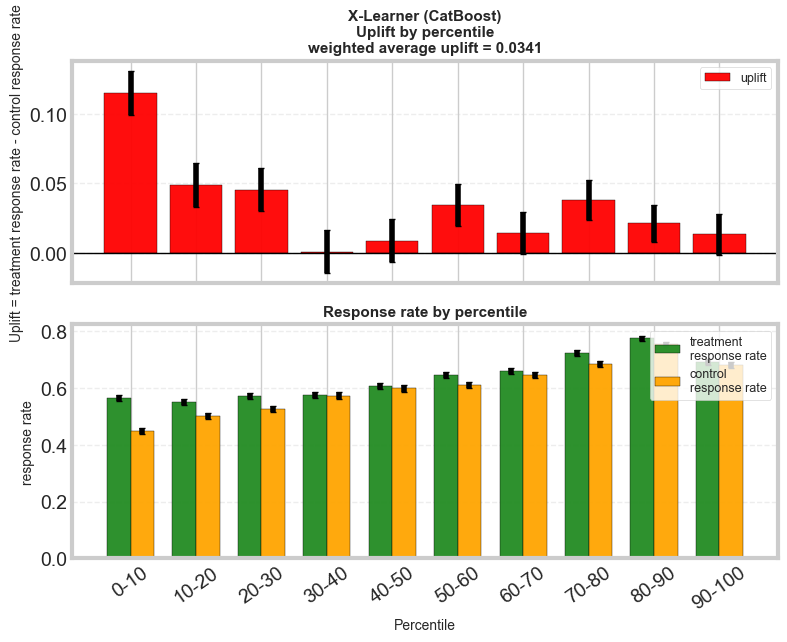

In [72]:
with mlflow.start_run(run_id=run_id):
    fig = plot_percentile_grid(
        preds_dict=test_holdout_preds,
        y_true=y_test_holdout,
        treatment=t_test_holdout,
        split_name='test_holdout',
        bins=10
    )
    mlflow.log_figure(fig, "uplift_by_percentile.png")
    plt.show()

# Добавление тега PRD

In [73]:
client = mlflow.tracking.MlflowClient()

client.set_registered_model_tag(name="model_tau_0", key="stage", value="PRD")
client.set_registered_model_tag(name="model_tau_1", key="stage", value="PRD")
client.set_registered_model_tag(name="model_propensity", key="stage", value="PRD")